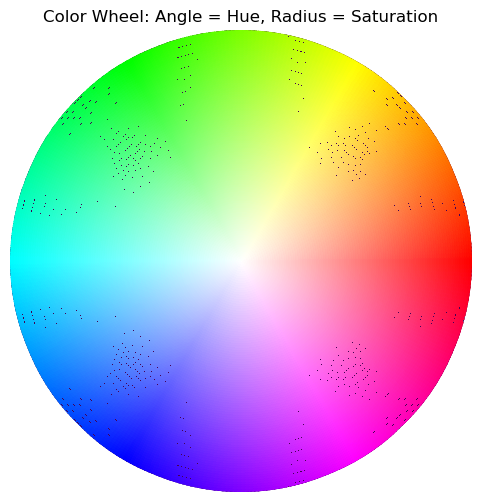

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import colorsys

# Define resolution of the color wheel
num_angles = 360  # Number of hue steps
num_radii = 100   # Number of intensity levels

# Create polar coordinate grid
theta = np.linspace(0, 2 * np.pi, num_angles)  # Hue varies with angle
r = np.linspace(0, 1, num_radii)  # Intensity varies radially
Theta, R = np.meshgrid(theta, r)

# Convert polar coordinates to RGB using HSV color space
H = Theta / (2 * np.pi)  # Hue (0 to 1)
S = R  # Saturation (0 to 1, increases radially)
V = np.ones_like(S)  # Brightness constant (1 for full brightness)

# Convert HSV to RGB
rgb = np.array([colorsys.hsv_to_rgb(h, s, v) for h, s, v in zip(H.flatten(), S.flatten(), V.flatten())])
rgb = rgb.reshape(H.shape + (3,))  # Reshape back to 2D image format

# Create figure
fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(6,6))

# Display color wheel
ax.pcolormesh(Theta, R, np.zeros_like(R), color=rgb.reshape(-1, 3), shading='auto')

# Remove labels and grid
ax.set_xticks([])
ax.set_yticks([])
ax.set_frame_on(False)

# Title
plt.title("Color Wheel: Angle = Hue, Radius = Saturation", fontsize=12)

# Show the plot
plt.show()

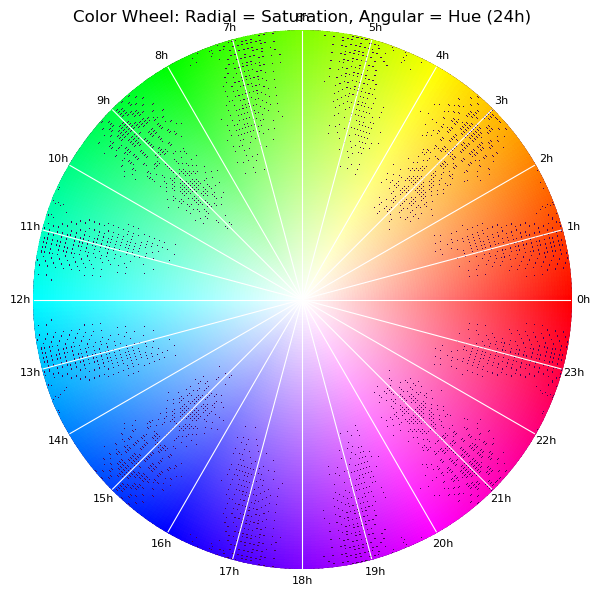

In [3]:


import numpy as np
import matplotlib.pyplot as plt
import colorsys

# Define resolution of the color wheel
num_angles = 360  # Number of hue steps
num_radii = 100   # Number of intensity levels

# Create polar coordinate grid
theta = np.linspace(0, 2 * np.pi, num_angles)
r = np.linspace(0, 1, num_radii)
Theta, R = np.meshgrid(theta, r)

# Convert polar coordinates to HSV, then to RGB
H = Theta / (2 * np.pi)  # Hue (0 to 1)
S = R  # Saturation (0 to 1, increasing radially)
V = np.ones_like(S)  # Brightness constant

# Convert HSV to RGB
rgb = np.array([colorsys.hsv_to_rgb(h, s, v) for h, s, v in zip(H.flatten(), S.flatten(), V.flatten())])
rgb = rgb.reshape(H.shape + (3,))  # Reshape to 2D image format

# Create figure
fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(7, 7))

# Display color wheel
ax.pcolormesh(Theta, R, np.zeros_like(R), color=rgb.reshape(-1, 3), shading='auto')

# Add hour segments and labels
for hour in range(24):
    angle = (hour / 24) * 2 * np.pi
    ax.plot([angle, angle], [0, 1], color='white', linewidth=0.8)
    label_angle = angle
    ax.text(label_angle, 1.05, f"{hour}h", ha='center', va='center', fontsize=8, color='black')

# Remove default polar labels and grid
ax.set_xticks([])
ax.set_yticks([])
ax.set_frame_on(False)

# Title
plt.title("Color Wheel: Radial = Saturation, Angular = Hue (24h)", fontsize=12)

# Show plot
plt.show()


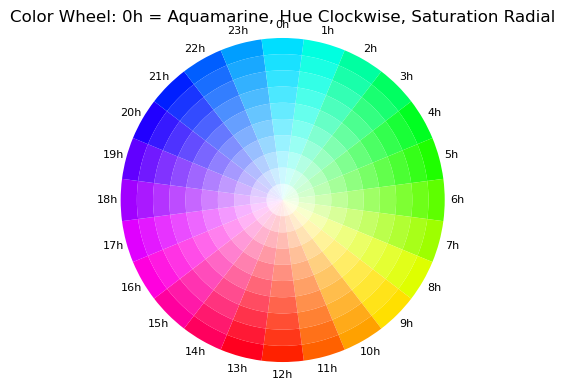

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import colorsys

# Parameters
num_hours = 24             # 24 azimuthal segments (1 per hour)
num_saturation_steps = 10  # 10 radial steps (saturation from 0 to 1)
aquamarine_hue = 0.48      # Approximate hue for aquamarine in HSV

# Define angular and radial boundaries
theta = np.linspace(0, 2 * np.pi, num_hours + 1)  # angles for 24 hours
r = np.linspace(0, 1, num_saturation_steps + 1)   # 10 saturation levels

# Set up plot
fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(4, 4))

# Reverse hue direction and set 0h at top
ax.set_theta_direction(-1)        # Clockwise
ax.set_theta_zero_location("N")   # Zero angle (0h) at top (North)

# Loop through radial and angular cells
for i in range(num_saturation_steps):
    for j in range(num_hours):
        theta1 = theta[j]
        theta2 = theta[j + 1]
        r1 = r[i]
        r2 = r[i + 1]

        # Hue decreases with hour (for clockwise effect), starting from aquamarine
        hue = (aquamarine_hue - j / num_hours) % 1.0
        saturation = r2
        value = 1.0
        rgb = colorsys.hsv_to_rgb(hue, saturation, value)

        ax.bar(x=(theta1 + theta2) / 2,
               height=r2 - r1,
               width=theta2 - theta1,
               bottom=r1,
               color=rgb,
               edgecolor='none',
               align='edge')

# Add hour labels
for hour in range(24):
    angle = (hour / 24) * 2 * np.pi
    ax.text(angle, 1.08, f"{hour}h", ha='center', va='center', fontsize=8, color='black')

# Clean up
ax.set_xticks([])
ax.set_yticks([])
ax.set_frame_on(False)
plt.title("Color Wheel: 0h = Aquamarine, Hue Clockwise, Saturation Radial", fontsize=12)

plt.tight_layout()


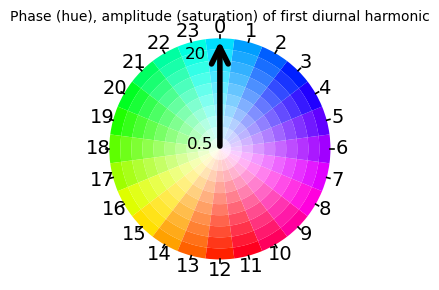

In [69]:
import numpy as np
import matplotlib.pyplot as plt
import colorsys

from matplotlib.patches import Circle, FancyArrowPatch

# Parameters
num_hours = 24
num_saturation_steps = 10
aquamarine_hue = 0.48  # HSV hue for aquamarine

# Angle and radius boundaries
theta = np.linspace(0, 2 * np.pi, num_hours + 1)
r = np.linspace(0, 1., num_saturation_steps + 1)

# Set up plot
fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(3., 3.))
ax.set_theta_direction(1)              # Counterclockwise
ax.set_theta_zero_location("N")        # 0h at the top

# Draw color segments (reversed hue direction)
for i in range(num_saturation_steps):
    for j in range(num_hours):
        theta1, theta2 = theta[j], theta[j + 1]
        r1, r2 = r[i], r[i + 1]
        hue = (aquamarine_hue - j / num_hours) % 1.0  # REVERSED hue
        saturation = r2
        value = 1.0
        rgb = colorsys.hsv_to_rgb(hue, saturation, value)

        ax.bar(
            x=(theta1 + theta2) / 2,
            height=r2 - r1,
            width=theta2 - theta1,
            bottom=r1,
            color=rgb,
            edgecolor='none',
            align='edge'
        )

# Add hour labels and short ticks
for hour in range(num_hours):
    angle = -(hour / 24) * 2 * np.pi
    ax.text(angle, 1.10, f"{hour}", ha='center', va='center', fontsize=14, color='black')
    ax.plot([angle, angle], [1.0, 1.03], color='black', lw=1.2)  # short radial tick

arrow = FancyArrowPatch(
    posA=(0., 0.),  # Start point below the circle
    posB=(0., 1.),  # End point above the circle
    arrowstyle='->',   # Arrow style
    mutation_scale=30, # Size of the arrow head
    color='black',       # Arrow color
    lw=4
)
ax.add_patch(arrow)
ax.annotate('0.5', xy=(0, 0), xytext=(-5, 0), textcoords='offset points', ha='right',fontsize=12)
ax.annotate('20', xy=(0, 0), xytext=(-10, 65), textcoords='offset points', ha='right',fontsize=12)


# Clean plot
ax.set_xticks([])
ax.set_yticks([])
ax.set_frame_on(False)
plt.title("Phase (hue), amplitude (saturation) of first diurnal harmonic",fontsize=10)
plt.tight_layout()
plt.show()